# House Price Linear Regression

## LV1 — Linear Regression from Scratch

This notebook implements **simple linear regression** using NumPy and Matplotlib.

### What is covered
- House size → house price prediction
- Linear model
- Squared-error cost function
- Gradient calculation
- Gradient descent
- Cost history visualization
- Feature scaling using standardization
- Final prediction for a new house

> **Note:** Regularization is intentionally not included in LV1. It will be added in LV2.


## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 2. Data

- **Feature (`x`)**: House size in square feet
- **Target (`y`)**: House price in lakhs


In [2]:
x_train = np.array([650, 800, 950, 1100, 1250, 1400, 1550, 1700, 1900, 2100])
y_train = np.array([32, 39, 46, 53, 60, 68, 74, 82, 91, 101])

print(f"x_train: {x_train}")
print(f"y_train: {y_train}")

print(f"x shape: {x_train.shape}")
print(f"y shape: {y_train.shape}")

m = x_train.shape[0]
print(f"Number of training examples: {m}")


x_train: [ 650  800  950 1100 1250 1400 1550 1700 1900 2100]
y_train: [ 32  39  46  53  60  68  74  82  91 101]
x shape: (10,)
y shape: (10,)
Number of training examples: 10


## 3. Linear Regression Model

In [3]:
# Initial parameter values for demonstration
w = 200
b = 100

print(f"w: {w}")
print(f"b: {b}")

def single_house_predict(x, w, b):
    return w * x + b

house_sqft = 650
print("Prediction for one house:", single_house_predict(house_sqft, w, b))


def compute_model(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)

    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb


tmp_f_wb = compute_model(x_train, w, b)
print(f"Prediction for all training examples: {tmp_f_wb}")


w: 200
b: 100
Prediction for one house: 130100
Prediction for all training examples: [130100. 160100. 190100. 220100. 250100. 280100. 310100. 340100. 380100.
 420100.]


## 4. Cost Function

The cost function used here is:

\[
J(w,b) = \frac{1}{2m}\sum_{i=0}^{m-1}(f_{w,b}(x_i)-y_i)^2
\]

This is the standard linear-regression squared-error cost with a `1/(2m)` factor. It is **not conventional MSE**, which uses `1/m`.


In [4]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0

    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum += cost

    total_cost = cost_sum / (2 * m)
    return total_cost


calculate_cost = compute_cost(x_train, y_train, w, b)
print(f"Total computed cost: {calculate_cost}")


Total computed cost: 40027534858.8


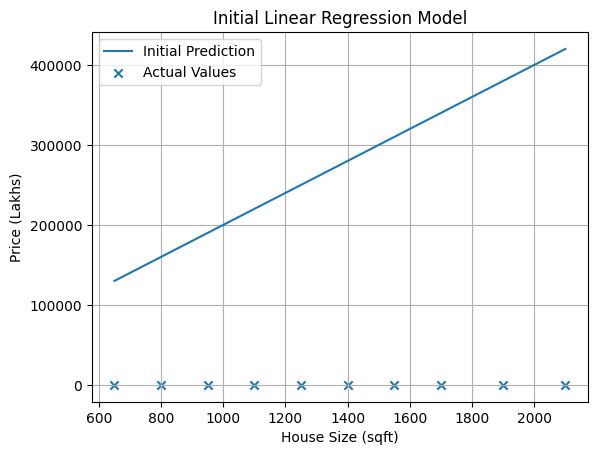

In [5]:
plt.plot(x_train, tmp_f_wb, label="Initial Prediction")
plt.scatter(x_train, y_train, marker="x", label="Actual Values")

plt.xlabel("House Size (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("Initial Linear Regression Model")
plt.legend()
plt.grid(True)
plt.show()


## 5. Gradient

In [6]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b

        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb - y[i])

        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


## 6. Gradient Descent

In [7]:
def gradient_descent(
    x, y, w_in, b_in, alpha, num_iters,
    cost_function, gradient_function
):
    b = b_in
    w = w_in

    c_history = []
    p_history = []

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        c_history.append(cost_function(x, y, w, b))
        p_history.append([w, b])

        # Print only selected iterations to avoid thousands of output lines
        if i % 1000 == 0 or i == num_iters - 1:
            print(
                f"Iteration: {i:4}, "
                f"Cost: {c_history[-1]:.4e}, "
                f"dj_dw: {dj_dw:.4e}, "
                f"dj_db: {dj_db:.4e}, "
                f"w: {w:.4e}, "
                f"b: {b:.4e}"
            )

    return w, b, c_history, p_history


In [8]:
# Gradient descent on the original, unscaled feature
w_init = 0
b_init = 0

iterations_count = 10000
alpha_unscaled = 1e-7

w_final, b_final, c_hist, p_hist = gradient_descent(
    x_train,
    y_train,
    w_init,
    b_init,
    alpha_unscaled,
    iterations_count,
    compute_cost,
    compute_gradient
)

print(f"Final parameters: w = {w_final:.4f}, b = {b_final:.4f}")
print(f"Final cost: {c_hist[-1]:.6f}")


Iteration:    0, Cost: 1.4837e+03, dj_dw: -9.6330e+04, dj_db: -6.4600e+01, w: 9.6330e-03, b: 6.4600e-06
Iteration: 1000, Cost: 9.2125e-02, dj_dw: 6.1040e-05, dj_db: -9.1150e-02, w: 4.8141e-02, b: 4.1362e-05
Iteration: 2000, Cost: 9.2124e-02, dj_dw: 6.1039e-05, dj_db: -9.1149e-02, w: 4.8141e-02, b: 5.0477e-05
Iteration: 3000, Cost: 9.2124e-02, dj_dw: 6.1039e-05, dj_db: -9.1148e-02, w: 4.8141e-02, b: 5.9592e-05
Iteration: 4000, Cost: 9.2123e-02, dj_dw: 6.1038e-05, dj_db: -9.1147e-02, w: 4.8141e-02, b: 6.8707e-05
Iteration: 5000, Cost: 9.2122e-02, dj_dw: 6.1038e-05, dj_db: -9.1146e-02, w: 4.8141e-02, b: 7.7822e-05
Iteration: 6000, Cost: 9.2121e-02, dj_dw: 6.1037e-05, dj_db: -9.1145e-02, w: 4.8141e-02, b: 8.6936e-05
Iteration: 7000, Cost: 9.2120e-02, dj_dw: 6.1036e-05, dj_db: -9.1145e-02, w: 4.8141e-02, b: 9.6051e-05
Iteration: 8000, Cost: 9.2119e-02, dj_dw: 6.1036e-05, dj_db: -9.1144e-02, w: 4.8141e-02, b: 1.0517e-04
Iteration: 9000, Cost: 9.2119e-02, dj_dw: 6.1035e-05, dj_db: -9.1143e-02

## 7. Cost History

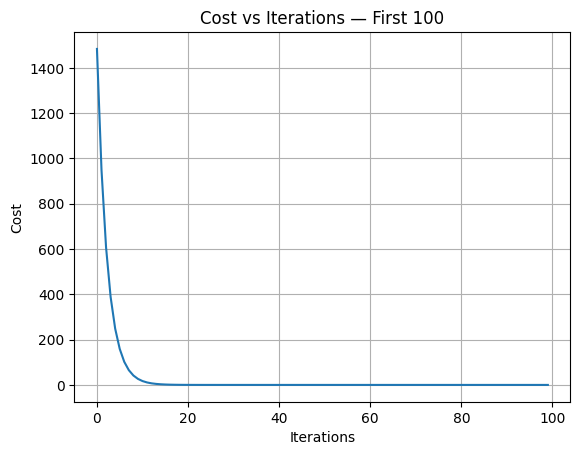

In [9]:
# First 100 iterations
plt.plot(range(100), c_hist[:100])

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations — First 100")
plt.grid(True)
plt.show()


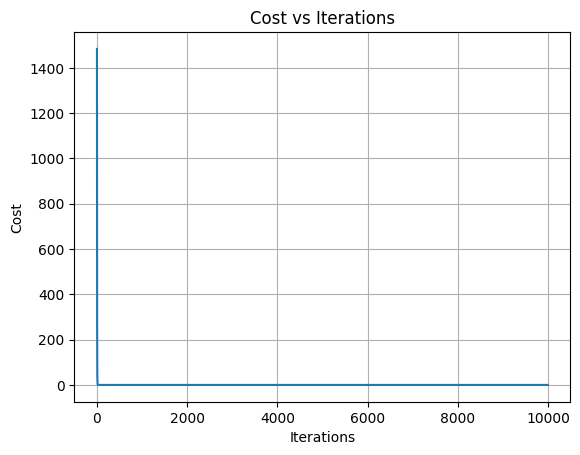

In [10]:
# Complete cost history
iterations = range(len(c_hist))

plt.plot(iterations, c_hist)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.grid(True)
plt.show()


## 8. Final Model Before Feature Scaling

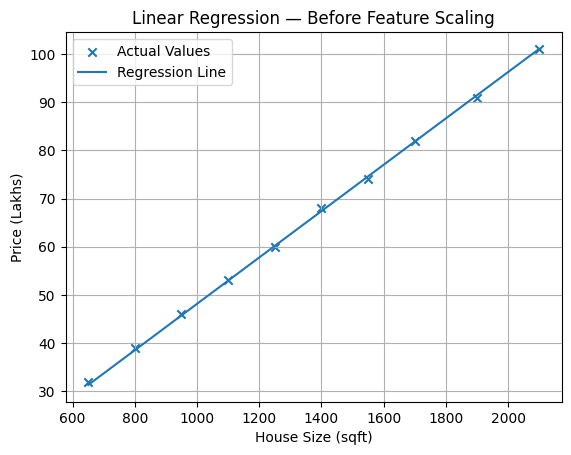

In [11]:
final_predictions = compute_model(x_train, w_final, b_final)

plt.scatter(x_train, y_train, marker="x", label="Actual Values")
plt.plot(x_train, final_predictions, label="Regression Line")

plt.xlabel("House Size (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("Linear Regression — Before Feature Scaling")
plt.legend()
plt.grid(True)
plt.show()


## 9. Feature Scaling

We use **standardization (Z-score normalization)**:

\[
x_{scaled} = \frac{x - \mu}{\sigma}
\]

where:
- `μ` = mean of the training feature
- `σ` = standard deviation of the training feature

Scaling changes the numerical range of the feature, which makes gradient descent easier to optimize.


In [12]:
x_mean = np.mean(x_train)
x_std = np.std(x_train)

x_scaled = (x_train - x_mean) / x_std

print("Mean:", x_mean)
print("Standard Deviation:", x_std)
print("Scaled X:", x_scaled)


Mean: 1340.0
Standard Deviation: 453.2107677449864
Scaled X: [-1.52247045 -1.19149861 -0.86052677 -0.52955494 -0.1985831   0.13238873
  0.46336057  0.79433241  1.23562819  1.67692397]


## 10. Gradient Descent with Scaled Features

In [13]:
w_scaled, b_scaled, c_hist_scaled, p_hist_scaled = gradient_descent(
    x_scaled,
    y_train,
    0,
    0,
    0.01,
    10000,
    compute_cost,
    compute_gradient
)

print(f"Scaled-model w: {w_scaled}")
print(f"Scaled-model b: {b_scaled}")
print(f"Final scaled-model cost: {c_hist_scaled[-1]}")


Iteration:    0, Cost: 2.2727e+03, dj_dw: -2.1548e+01, dj_db: -6.4600e+01, w: 2.1548e-01, b: 6.4600e-01
Iteration: 1000, Cost: 5.1660e-02, dj_dw: -9.3027e-04, dj_db: -2.7889e-03, w: 2.1548e+01, b: 6.4597e+01
Iteration: 2000, Cost: 5.1655e-02, dj_dw: -4.0161e-08, dj_db: -1.2040e-07, w: 2.1548e+01, b: 6.4600e+01
Iteration: 3000, Cost: 5.1655e-02, dj_dw: -1.7400e-12, dj_db: -5.1955e-12, w: 2.1548e+01, b: 6.4600e+01
Iteration: 4000, Cost: 5.1655e-02, dj_dw: -1.7512e-13, dj_db: -7.0344e-13, w: 2.1548e+01, b: 6.4600e+01
Iteration: 5000, Cost: 5.1655e-02, dj_dw: -1.7512e-13, dj_db: -7.0344e-13, w: 2.1548e+01, b: 6.4600e+01
Iteration: 6000, Cost: 5.1655e-02, dj_dw: -1.7512e-13, dj_db: -7.0344e-13, w: 2.1548e+01, b: 6.4600e+01
Iteration: 7000, Cost: 5.1655e-02, dj_dw: -1.7512e-13, dj_db: -7.0344e-13, w: 2.1548e+01, b: 6.4600e+01
Iteration: 8000, Cost: 5.1655e-02, dj_dw: -1.7512e-13, dj_db: -7.0344e-13, w: 2.1548e+01, b: 6.4600e+01
Iteration: 9000, Cost: 5.1655e-02, dj_dw: -1.7512e-13, dj_db: -7

In [14]:
# Compare the final costs
print(f"Final cost without scaling: {c_hist[-1]:.6f}")
print(f"Final cost with scaling:    {c_hist_scaled[-1]:.6f}")


Final cost without scaling: 0.092118
Final cost with scaling:    0.051655


## 11. Final Model with Feature Scaling

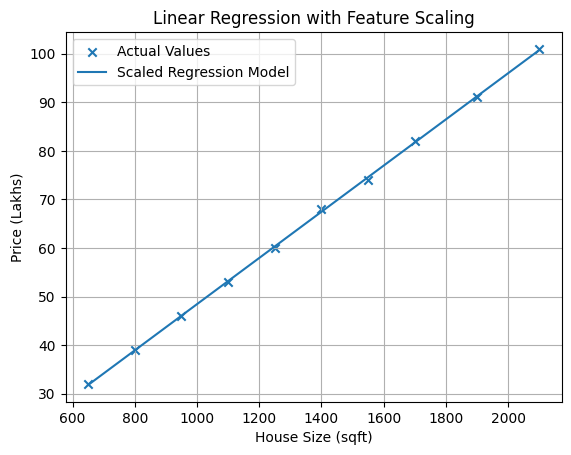

In [15]:
scaled_predictions = compute_model(x_scaled, w_scaled, b_scaled)

plt.scatter(x_train, y_train, marker="x", label="Actual Values")
plt.plot(x_train, scaled_predictions, label="Scaled Regression Model")

plt.xlabel("House Size (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("Linear Regression with Feature Scaling")
plt.legend()
plt.grid(True)
plt.show()


## 12. Predict the Price of a New House

The new input must be scaled using the **same mean and standard deviation calculated from the training data** before passing it to the trained model.


In [16]:
new_house = 1500

# Scale the new input using training-data statistics
new_house_scaled = (new_house - x_mean) / x_std

# Predict using the scaled model
predicted_price = single_house_predict(
    new_house_scaled,
    w_scaled,
    b_scaled
)

print(f"Predicted price for {new_house} sqft house: {predicted_price:.2f} Lakhs")


Predicted price for 1500 sqft house: 72.21 Lakhs


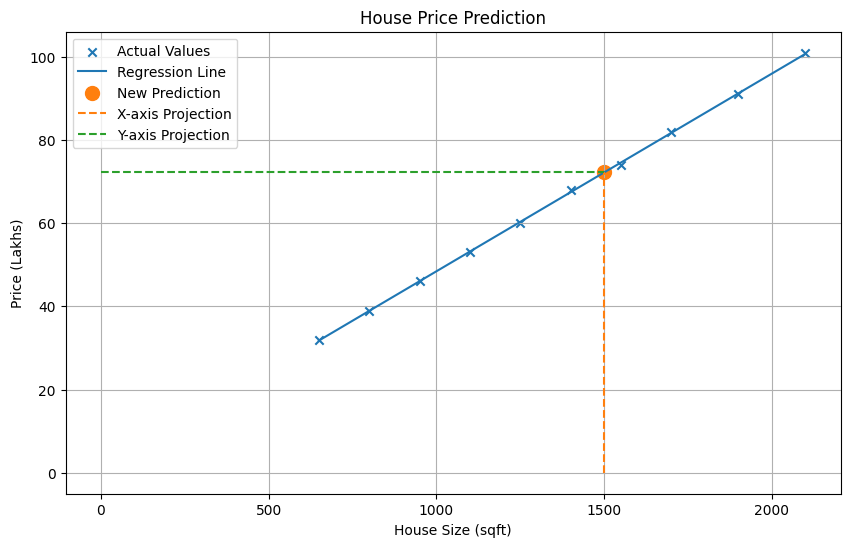

In [17]:
# Visualize the new prediction using the original sqft axis
plt.figure(figsize=(10, 6))

plt.scatter(x_train, y_train, marker="x", label="Actual Values")
plt.plot(x_train, scaled_predictions, label="Regression Line")

plt.scatter(
    new_house,
    predicted_price,
    marker="o",
    s=100,
    label="New Prediction"
)

# Projection to the x-axis
plt.plot(
    [new_house, new_house],
    [0, predicted_price],
    linestyle="--",
    label="X-axis Projection"
)

# Projection to the y-axis
plt.plot(
    [0, new_house],
    [predicted_price, predicted_price],
    linestyle="--",
    label="Y-axis Projection"
)

plt.xlabel("House Size (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("House Price Prediction")
plt.legend()
plt.grid(True)
plt.show()


## LV1 Summary

The model now includes:

- Simple linear regression
- Cost function
- Gradient calculation
- Gradient descent
- Cost visualization
- Feature scaling
- Scaled-model training
- New-house prediction

**Regularization is intentionally excluded from LV1 and will be implemented in LV2.**
